__Titanic Survival Prediction using Classification Models__

Import Required Libraries and Load Titanic Dataset

In [13]:
# Import pandas for handling datasets
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import functions for splitting data
from sklearn.model_selection import train_test_split

# Import preprocessing tools
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Import classification model
from sklearn.linear_model import LogisticRegression

# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# Support Vector Machine
from sklearn.svm import SVC

# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Titanic dataset from seaborn library
titanic = sns.load_dataset("titanic")

# Display first 5 rows of the dataset
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [14]:
# Check dataset size
titanic.shape

# View column names and data types
titanic.info()

# Check missing values
titanic.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Data Cleaning:Remove unnecessary columns and Handle Missing Values

In [15]:
# Removing columns which are not useful for prediction
titanic.drop(
    [
        'deck',
        'embark_town',
        'alive',
        'class',
        'who',
        'adult_male'
    ],
    axis=1,
    inplace=True
)

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [16]:
# Filling missing age values with mean age
titanic['age'].fillna(
    titanic['age'].mean(),
    inplace=True
)
# Filling missing embarked values with most frequent value
titanic['embarked'].fillna(
    titanic['embarked'].mode()[0],
    inplace=True
)
# Checking missing values again
titanic.isnull().sum()

C:\Users\24eu02012\AppData\Local\Temp\ipykernel_13284\2393379908.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(
C:\Users\24eu02012\AppData\Local\Temp\ipykernel_13284\2393379908.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing '

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64

Convert Categorical Data into Numerical Data

In [17]:
# Creating encoder
encoder = LabelEncoder()
# Convert sex column
# female = 0
# male = 1
titanic['sex'] = encoder.fit_transform(
    titanic['sex']
)
# Convert embarked column
titanic['embarked'] = encoder.fit_transform(
    titanic['embarked']
)
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.0,1,0,7.2500,2,False
1,1,1,0,38.0,1,0,71.2833,0,False
2,1,3,0,26.0,0,0,7.9250,2,True
3,1,1,0,35.0,1,0,53.1000,2,False
4,0,3,1,35.0,0,0,8.0500,2,True


Select Features and Target

In [18]:
# Input features
X = titanic.drop(
    'survived',
    axis=1
)
# Output variable
y = titanic['survived']
print(X.shape)
print(y.shape)

(891, 8)
(891,)


Split Dataset

In [19]:
# Splitting data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (712, 8)
Testing Data: (179, 8)


Feature Scaling

In [20]:
# Scaling features for better performance
scaler = StandardScaler()
X_train = scaler.fit_transform(
    X_train
)
X_test = scaler.transform(
    X_test
)

Logistic Regression Model

In [21]:
# Create Logistic Regression model
lr_model = LogisticRegression()
# Train model
lr_model.fit(
    X_train,
    y_train
)
# Prediction
lr_prediction = lr_model.predict(
    X_test
)
# Accuracy
lr_accuracy = accuracy_score(
    y_test,
    lr_prediction
)
print(
    "Logistic Regression Accuracy:",
    lr_accuracy
)

Logistic Regression Accuracy: 0.8044692737430168


Decision Tree Classifier

In [22]:
# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42
)
# Train model
dt_model.fit(
    X_train,
    y_train
)
# Prediction
dt_prediction = dt_model.predict(
    X_test
)
# Accuracy
dt_accuracy = accuracy_score(
    y_test,
    dt_prediction
)
print(
    "Decision Tree Accuracy:",
    dt_accuracy
)

Decision Tree Accuracy: 0.776536312849162


Random Forest Classifier

In [23]:
# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
# Train model
rf_model.fit(
    X_train,
    y_train
)
# Prediction
rf_prediction = rf_model.predict(
    X_test
)
# Accuracy
rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)
print(
    "Random Forest Accuracy:",
    rf_accuracy
)

Random Forest Accuracy: 0.8156424581005587


Support Vector Machine (SVM)

In [24]:
# Create SVM model
svm_model = SVC()
# Train model
svm_model.fit(
    X_train,
    y_train
)
# Prediction
svm_prediction = svm_model.predict(
    X_test
)
# Accuracy
svm_accuracy = accuracy_score(
    y_test,
    svm_prediction
)
print(
    "SVM Accuracy:",
    svm_accuracy
)

SVM Accuracy: 0.8156424581005587


Compare All Models

In [25]:
# Creating comparison table
results = pd.DataFrame(
    {
        "Model":
        [
            "Logistic Regression",
            "Decision Tree",
            "Random Forest",
            "SVM"
        ],

        "Accuracy":
        [
            lr_accuracy,
            dt_accuracy,
            rf_accuracy,
            svm_accuracy
        ]
    }
)
results

,Model,Accuracy
0,Logistic Regression,0.804469
1,Decision Tree,0.776536
2,Random Forest,0.815642
3,SVM,0.815642


Confusion Matrix

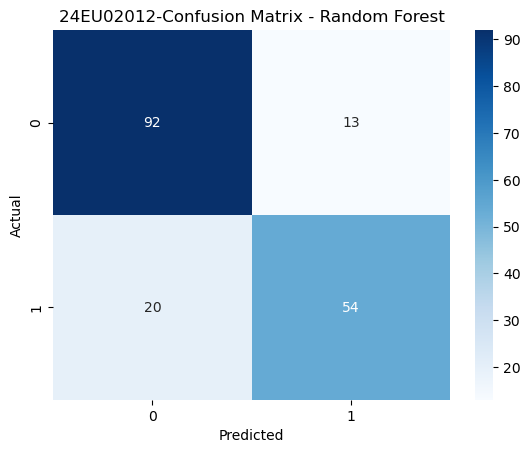

In [26]:
# Choose Random Forest predictions
cm = confusion_matrix(
    y_test,
    rf_prediction
)
# Plot heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("24EU02012-Confusion Matrix - Random Forest")
plt.show()

 Classification Report

In [27]:
# Precision, Recall and F1-score
print(
    classification_report(
        y_test,
        rf_prediction
    )
)

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       105
           1       0.81      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179

